# 1. Información del Proyecto
- Nombre del proyecto:
- Autor: Juan Ramon Reyes Torres
- Descripción breve: Este proyecto consiste en analizar una base de datos con el propósito de identificar y predecir posibles fraudes mediante técnicas de análisis de datos y aprendizaje automático.
- Objetivo principal: Predecir y detectar los fraudes presentes en una base de datos para mejorar la seguridad y prevenir futuras actividades fraudulentas.
- Preguntas a responder: 
¿Cuantos fraudes existen en la base de datos?
¿Qué características tienen las transacciones fraudulentas?
¿Es posible predecir futuros fraudes utilizando modelos de machine learning?

## 2. Contexto y Antecedentes
- ¿Cuál es el problema? Actualmente, muchas organizaciones manejan grandes cantidades de información y transacciones, lo que aumenta el riesgo de actividades fraudulentas. Detectar estos fraudes manualmente es complicado, lento y propenso a errores.
- ¿Por qué es importante? Es importante poder identificar y visualizar los fraudes que se han realizado para mejorar la seguridad de los datos, reducir pérdidas económicas y fortalecer los sistemas de prevención a futuro.
- ¿Qué decisiones dependen de este análisis? Implementar medidas de seguridad más efectivas.
Mejorar los sistemas de monitoreo de transacciones.
Detectar patrones sospechosos de manera temprana.
Optimizar la toma de decisiones relacionadas con prevención de fraudes.
- Supuestos iniciales:La base de datos contiene registros marcados como fraude y no fraude.
Existen patrones o comportamientos que permiten identificar actividades fraudulentas.
Los datos disponibles son suficientes para entrenar modelos predictivos.
Las variables de la base de datos influyen en la detección de fraudes.

## 3. Fuente y Descripción de los Datos
- Archivos utilizados: creditcard2026.csv
- Procedencia de los datos: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
- Limitaciones conocidas:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 4. Carga de Datos

In [2]:
df = pd.read_csv('Fraud_detection_data/creditcard2026.csv')

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 5. Exploración Inicial (EDA)
- Vista general
- Estadísticas descriptivas
- Distribuciones
- Outliers
- Faltantes

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [6]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [7]:
df.nunique()

Time      124592
V1        275663
V2        275663
V3        275663
V4        275663
V5        275663
V6        275663
V7        275663
V8        275663
V9        275663
V10       275663
V11       275663
V12       275663
V13       275663
V14       275663
V15       275663
V16       275663
V17       275663
V18       275663
V19       275663
V20       275663
V21       275663
V22       275663
V23       275663
V24       275663
V25       275663
V26       275663
V27       275663
V28       275663
Amount     32767
Class          2
dtype: int64

In [8]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

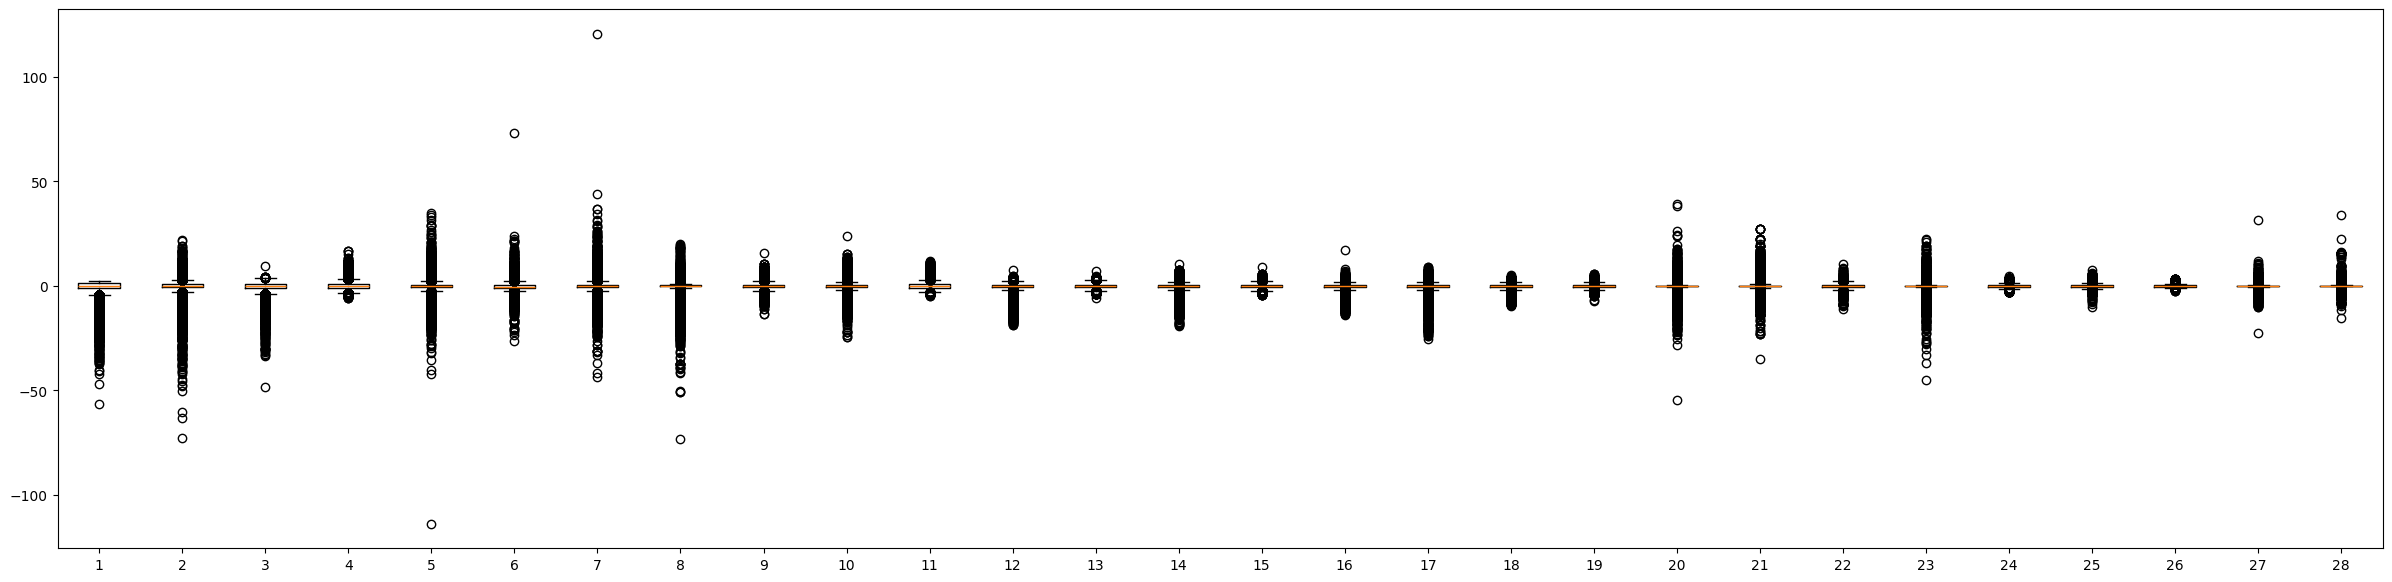

In [9]:
plt.figure(figsize=(30,7))
boxplot = df.drop(columns=['Time','Amount','Class'])
plt.boxplot(boxplot);

### Casos fraudulentos totales

In [10]:
total_cases = df['Class'].value_counts()
total_cases_percent = df['Class'].value_counts(normalize=True)

print(total_cases)
print(total_cases_percent.round(3))

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    0.998
1    0.002
Name: proportion, dtype: float64


([<matplotlib.axis.XTick at 0x23b437ddbd0>,
 [Text(0, 0, '0'), Text(1, 0, '1')])

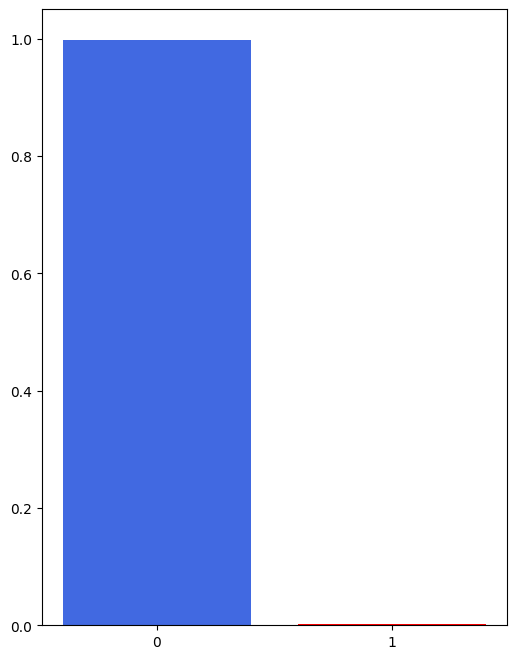

In [11]:
color = ['royalblue', 'red']
plt.figure(figsize=(6,8))
plt.bar(total_cases_percent.index , total_cases_percent.values, color=color)
plt.ylim(0,1.05)
plt.xticks([0,1])

### Error mas caro?

In [12]:
class_1 = df[df['Class'] == 1]
class_1_sorted = class_1['Amount'].sort_values(ascending=False)
class_1_sorted

176049    2125.87
6971      1809.68
249167    1504.93
89190     1402.16
81609     1389.56
           ...   
93486        0.00
93788        0.00
274382       0.00
69980        0.00
8842         0.00
Name: Amount, Length: 492, dtype: float64

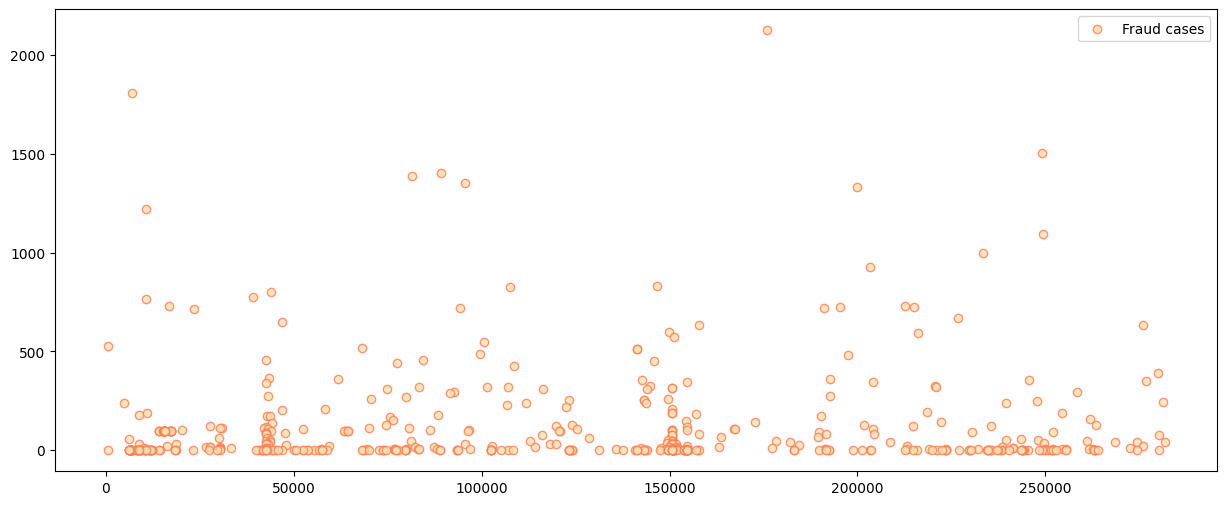

In [13]:
plt.figure(figsize=(15,6))
plt.scatter(class_1_sorted.index, class_1_sorted.values, label='Fraud cases', alpha= .8, color= 'wheat', edgecolor='coral')
plt.legend()

## 6. Limpieza de Datos
- Tratamiento de faltantes (N/A)
- Outliers
- Tipos de datos
- Normalización/codificación

### 6.1 Normalizacion

In [14]:
# Metodo de estandarizacion
df_normalize = df.copy()
column = 'Amount'
df_normalize[column] = (df_normalize[column] - df_normalize[column].mean()) / df_normalize[column].std()    

In [15]:
display(df_normalize)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244964,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342474,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.160684,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.140534,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073403,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,-0.350150,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,-0.254116,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,-0.081839,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,-0.313248,0


## 7. Análisis Profundo
- Correlaciones
- Visualizaciones clave
- Hallazgos

### 7.1 Correlaciones

In [16]:
corr = df_normalize.corr()

In [17]:
corr.round(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
Time,1.00000,0.11740,-0.01059,-0.41962,-0.10526,0.17307,-0.06302,0.08471,-0.03695,-0.00866,...,0.04474,0.14406,0.05114,-0.01618,-0.23308,-0.04141,-0.00513,-0.00941,-0.01060,-0.01232
V1,0.11740,1.00000,0.00000,-0.00000,-0.00000,0.00000,-0.00000,-0.00000,-0.00000,-0.00000,...,-0.00000,-0.00000,0.00000,-0.00000,-0.00000,-0.00000,0.00000,0.00000,-0.22771,-0.10135
V2,-0.01059,0.00000,1.00000,0.00000,-0.00000,0.00000,0.00000,0.00000,-0.00000,0.00000,...,-0.00000,0.00000,0.00000,0.00000,-0.00000,0.00000,-0.00000,-0.00000,-0.53141,0.09129
V3,-0.41962,-0.00000,0.00000,1.00000,0.00000,-0.00000,0.00000,0.00000,-0.00000,0.00000,...,0.00000,-0.00000,-0.00000,0.00000,-0.00000,-0.00000,0.00000,0.00000,-0.21088,-0.19296
V4,-0.10526,-0.00000,-0.00000,0.00000,1.00000,-0.00000,-0.00000,-0.00000,0.00000,0.00000,...,-0.00000,-0.00000,0.00000,0.00000,0.00000,-0.00000,0.00000,-0.00000,0.09873,0.13345
V5,0.17307,0.00000,0.00000,-0.00000,-0.00000,1.00000,0.00000,0.00000,0.00000,0.00000,...,-0.00000,0.00000,-0.00000,-0.00000,0.00000,0.00000,0.00000,-0.00000,-0.38636,-0.09497
V6,-0.06302,-0.00000,0.00000,0.00000,-0.00000,0.00000,1.00000,0.00000,-0.00000,0.00000,...,0.00000,-0.00000,0.00000,-0.00000,0.00000,-0.00000,-0.00000,0.00000,0.21598,-0.04364
V7,0.08471,-0.00000,0.00000,0.00000,-0.00000,0.00000,0.00000,1.00000,0.00000,0.00000,...,-0.00000,-0.00000,-0.00000,0.00000,-0.00000,-0.00000,-0.00000,-0.00000,0.39731,-0.18726
V8,-0.03695,-0.00000,-0.00000,-0.00000,0.00000,0.00000,-0.00000,0.00000,1.00000,0.00000,...,0.00000,0.00000,0.00000,-0.00000,-0.00000,-0.00000,0.00000,-0.00000,-0.10308,0.01988
V9,-0.00866,-0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,1.00000,...,0.00000,-0.00000,-0.00000,-0.00000,0.00000,-0.00000,-0.00000,0.00000,-0.04425,-0.09773


<Axes: >

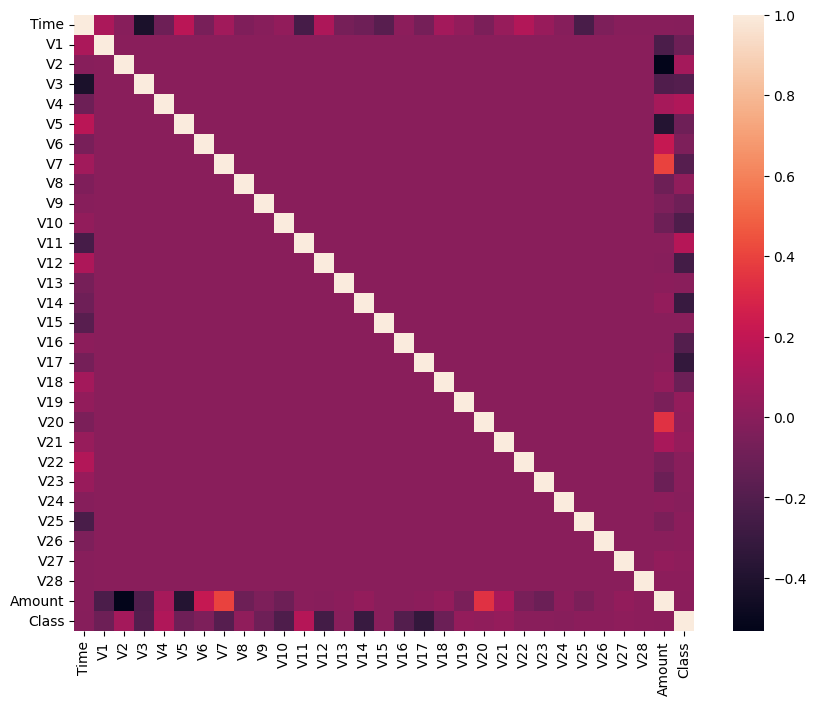

In [18]:
plt.figure(figsize=(10,8))
sns.heatmap(corr)

In [19]:
corr['Class'].sort_values(ascending=False)

Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64

### 7.3 Visualizaciones clave

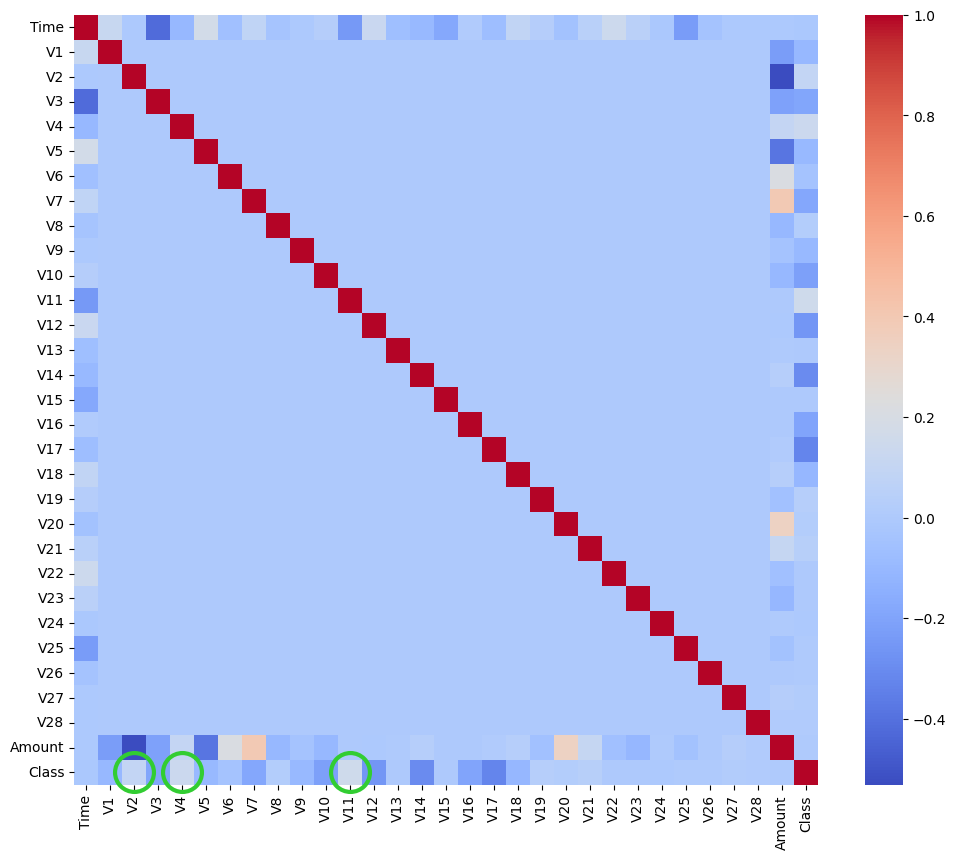

In [20]:
plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm')
coords = [(30.5, 11.5), (30.5, 4.5), (30.5,2.5)]  
for y, x in coords:
    plt.plot(x, y, marker= 'o', fillstyle= 'none', markersize= 28, markeredgewidth= 3, markeredgecolor= 'limegreen', clip_on=False)


### 7.4 Hallazgos

La matriz de correlación no mostró relaciones lineales extremadamente fuertes entre la mayoría de variables, la detección de fraude parece depender de combinaciones complejas de variables y no únicamente de relaciones lineales simples. Aunque las correlaciones individuales no son muy altas, múltiples variables podrían aportar información relevante en conjunto dentro de modelos de machine learning.

## 8. Ingeniería de Características
- Nuevas variables
- Transformaciones
- Selección de features

En esta Base de datos, ya fueron hechos los features desde el principio. (V1...V28)

## 9. Preparación para Modelado
- Train/test
- Escalado
- Técnicas seleccionadas

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from xgboost import XGBClassifier


In [22]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

Para esta base de datos, no es necesaria la columna 'Time' Ya que esta lo unico que representa es el tiempo que hubo desde cada transacción junto con la primer transacción 

In [23]:
X = df.drop(columns=['Class','Time'],axis= 1, inplace=False)
y = df['Class']

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## 10. Modelado
- Modelos probados
- Parámetros

In [25]:
rf_model = RandomForestClassifier(class_weight= 'balanced_subsample', random_state=42)
rf_model.fit(X_train,y_train) 

xgb_model = XGBClassifier(random_state= 42, )
xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [26]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
y_train.value_counts(normalize=True)
y_test.value_counts(normalize=True)

Class
0    0.99828
1    0.00172
Name: proportion, dtype: float64

In [28]:
rf_pred = rf_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)

## 11. Evaluación
- Métricas
- Gráficas
- Comparación
- Interpretación

### 11.1 métricas

In [29]:
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("Evaluacion de precision: ", rf_precision)
print("Evaluacion de Recall: ", rf_recall)
print("Evaluacion de F1: ", rf_f1)

Evaluacion de precision:  0.961038961038961
Evaluacion de Recall:  0.7551020408163265
Evaluacion de F1:  0.8457142857142858


In [30]:
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)

print("Evaluacion de precision: ", xgb_precision)
print("Evaluacion de Recall: ", xgb_recall)
print("Evaluacion de F1: ", xgb_f1)

Evaluacion de precision:  0.8764044943820225
Evaluacion de Recall:  0.7959183673469388
Evaluacion de F1:  0.8342245989304813


### 11.2 gráficas

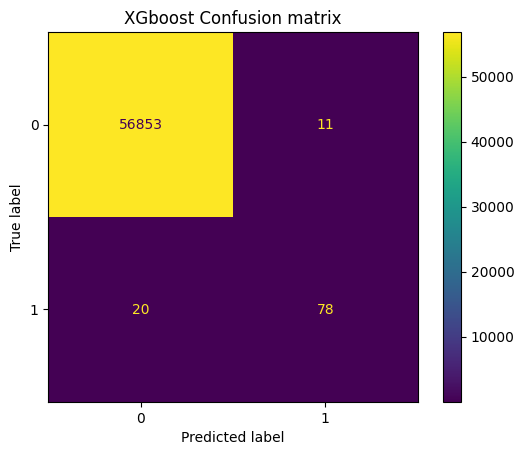

In [31]:
xgb_cm = confusion_matrix(y_test, xgb_pred, labels=rf_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=xgb_cm,
display_labels=xgb_model.classes_)
disp.plot()
plt.title('XGboost Confusion matrix')
plt.show()

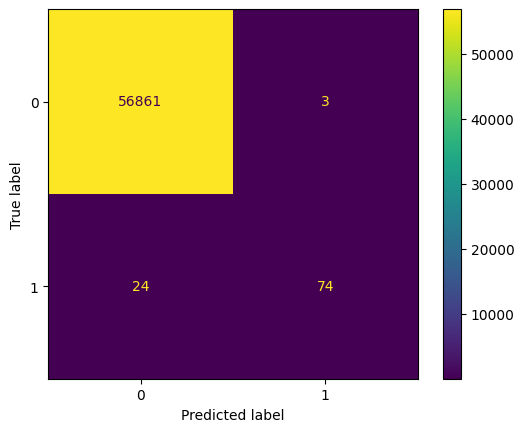

In [32]:
rf_cm = confusion_matrix(y_test, rf_pred, labels=rf_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=rf_cm,
display_labels=rf_model.classes_)
disp.plot()
plt.show()

### 11.3 comparación

In [33]:
data = {
    'precision score' : [rf_precision, xgb_precision],
    'recall score ' : [rf_recall, xgb_recall],
    'F1 score' : [rf_f1,xgb_f1]
    }

metricas = pd.DataFrame(data)

metricas.index = ['Random Forest', 'XGBoost']
metricas

,precision score,recall score,F1 score
Random Forest,0.961039,0.755102,0.845714
XGBoost,0.876404,0.795918,0.834225


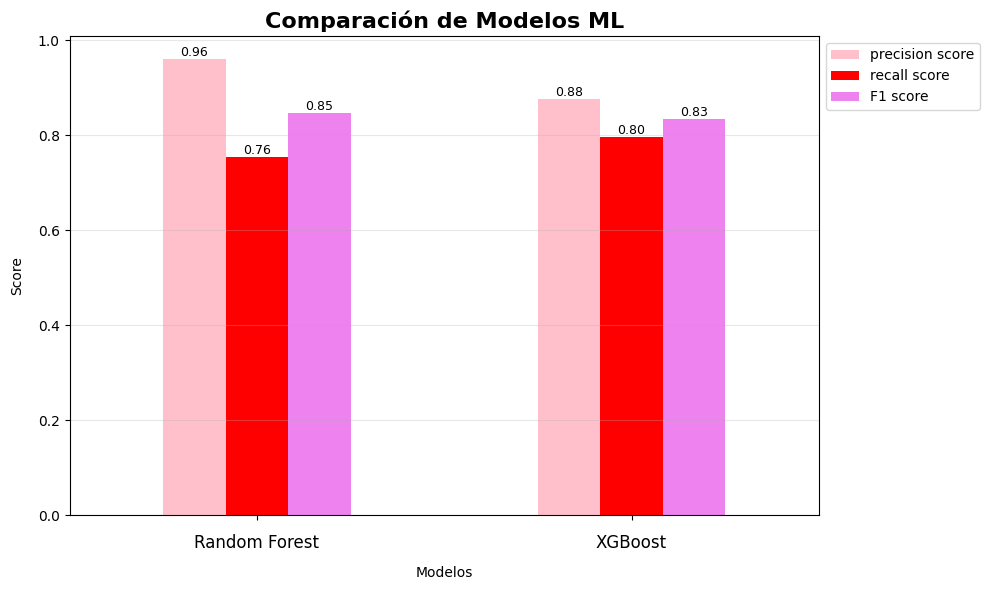

In [34]:
fig, ax = plt.subplots(figsize=(10,6))

colors = ['pink','red','violet']

ax = metricas.plot(kind='bar', ax=ax, color=colors, legend=True)

# Iterar sobre los patches (barras) del axes
for bar in ax.patches:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height,
            f'{height:.2f}', ha='center', va='bottom', fontsize=9)

ax.set_title('Comparación de Modelos ML', fontsize=16, fontweight='bold')
ax.set_ylabel('Score', labelpad=10)
ax.set_xlabel('Modelos', labelpad=10)
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', alpha=0.3)
ax.set_xticklabels(['Random Forest','XGBoost'], fontsize=12)
ax.tick_params(axis='x', pad=10)
ax.legend(bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

### 11.4 interpretación

El modelo de Random Forest tiene una presición del 96% comparado con el modelo XGBoost que solo tiene 88%, la metrica de recall y F1 se mantienen muy parecidas, con todo esto visto se decidió usar mejor el modelo de XGBoost para seguir con la investigación, ya que Es mejor para detectar mas fraudes.Random Forest tiene mayor precision, pero XGBoost tiene mayor recall.
En fraude, mayor recall puede ser preferible porque reduce fraudes no detectados, pero eso puede aumentar falsos positivos.
En este Projecto vamos a irnos por el XGBoost para detectar más fraudes.

## 13. Resultados Finales
- Conclusiones
- Insights clave
- Limitaciones

### Conclusiones

El proyecto permitió construir y comparar modelos de clasificación para la detección de transacciones fraudulentas. Durante el análisis exploratorio se observó un fuerte desbalance entre las clases, ya que la mayoría de las transacciones corresponden a casos no fraudulentos. Por esta razón, métricas como accuracy no son suficientes para evaluar el desempeño del modelo. Se compararon los modelos Random Forest y XGBoost utilizando precision, recall y F1-score. Random Forest mostró una mayor precision, lo que significa que cuando predice fraude tiende a equivocarse menos. Sin embargo, XGBoost obtuvo un mayor recall, por lo que fue capaz de detectar una mayor proporción de fraudes reales. Dado que en un problema de fraude suele ser más costoso no detectar una transacción fraudulenta que revisar una transacción legítima marcada como sospechosa, se considera que XGBoost puede ser una opción más adecuada si el objetivo principal es reducir los falsos negativos.

### Insights Clave

- El dataset presenta un desbalance de clases muy marcado, por lo que el uso de métricas como precision, recall y F1-score es más adecuado que usar solamente accuracy.
- Las variables no muestran correlaciones lineales extremadamente fuertes con la variable objetivo, lo que sugiere que la detección de fraude depende de combinaciones más complejas entre variables.
- Random Forest ofrece mejor precision, reduciendo falsos positivos.
- XGBoost ofrece mejor recall, detectando más casos reales de fraude.
- En problemas de fraude, el recall tiene un peso importante porque los falsos negativos pueden representar pérdidas económicas o riesgos para el cliente.

### Limitaciones

- No se realizó una optimización profunda de hiperparámetros, por lo que los modelos podrían mejorar con GridSearchCV o RandomizedSearchCV.
- No se evaluaron métricas adicionales como ROC-AUC o Precision-Recall AUC, que son útiles en datasets altamente desbalanceados.
- Las variables V1 a V28 ya vienen transformadas, por lo que la interpretación directa de cada feature es limitada.
- El modelo no fue evaluado en datos nuevos fuera del dataset original, por lo que no se puede garantizar su rendimiento en producción.

## 14. Recomendaciones

- Priorizar modelos con buen recall si el objetivo principal es detectar la mayor cantidad posible de fraudes.
- Analizar cuidadosamente los falsos positivos, ya que demasiadas alertas incorrectas pueden afectar la experiencia del cliente.
- Usar validación cruzada para obtener una evaluación más robusta.
- En un entorno real, el modelo debería funcionar como sistema de alerta, no como decisión automática final.

## 15. Checklist Final
- [X] Datos limpios
- [X] EDA completo
- [X] Features creados
- [X] Modelos evaluados
- [X] Resultados documentados